In [ ]:
import zipfile
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

In [ ]:
!pip install gdown
import gdown

In [ ]:
file_id = "1KEwL97mJH-B1VTXAK4_WAOkE4kfCQlEB"
gdown.download(f"https://drive.google.com/uc?id={file_id}", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1KEwL97mJH-B1VTXAK4_WAOkE4kfCQlEB
From (redirected): https://drive.google.com/uc?id=1KEwL97mJH-B1VTXAK4_WAOkE4kfCQlEB&confirm=t&uuid=ecbee71f-1941-48cc-936c-b6beb3f1f554
To: /home/jovyan/Copy of waterPuddle.zip
100% 825M/825M [00:09<00:00, 90.9MB/s] 


'Copy of waterPuddle.zip'

In [ ]:
zip_path = "Copy of waterPuddle.zip"
extract_path = "work/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Check contents
os.listdir(extract_path)

['test', 'train', 'waterPuddle']

In [ ]:
import os

# Adjust path if needed
data_dir = "work/waterPuddle"
for root, dirs, files in os.walk(data_dir):
    print(f"\n📂 Directory: {root}")
    for file in files[:5]:  # show up to 5 files per folder
        print("   └──", file)


📂 Directory: work/waterPuddle

📂 Directory: work/waterPuddle/imgs

📂 Directory: work/waterPuddle/imgs/3
   └── 22048.jpg
   └── 260110.jpg
   └── 3023.jpg
   └── 240422200.jpg
   └── 3059.jpg

📂 Directory: work/waterPuddle/imgs/4
   └── 36076.jpg
   └── 40103.jpg
   └── 47077.jpg
   └── 40108.jpg
   └── 5074.jpg

📂 Directory: work/waterPuddle/imgs/1
   └── 12018.jpg
   └── 1068.jpg
   └── 080.jpg
   └── 090.jpg
   └── 10111.jpg

📂 Directory: work/waterPuddle/imgs/2
   └── 14099.jpg
   └── 200106.jpg
   └── 20095.jpg
   └── 20Road.jpg
   └── 2021-08-03-pothole-1200x630.jpg

📂 Directory: work/waterPuddle/imgs/5
   └── 7035.jpg
   └── 71028.jpg
   └── dirty-road-with-puddle-during-rain-season-puddle-in-dirt-roa.jpg
   └── 7092.jpg
   └── 7022.jpg

📂 Directory: work/waterPuddle/imgs/6
   └── img-000001882.png
   └── img-000001401.png
   └── img-000001061.png
   └── img-000003381.png
   └── img-000002053.png

📂 Directory: work/waterPuddle/imgs/7
   └── pothole-roads-of-Mumbai-781x441.jpg
 

In [ ]:
!pip install opencv-python


In [ ]:
import cv2
import matplotlib.pyplot as plt

def load_image_and_annotation(class_id, img_name=None):
    img_dir = f"/content/waterPuddle/imgs/{class_id}"
    ann_dir = f"/content/waterPuddle/annotations/{class_id}"

    # List files
    img_files = sorted(os.listdir(img_dir))
    ann_files = sorted(os.listdir(ann_dir))

    # Pick a specific file or the first one
    if img_name is None:
        img_name = img_files[0]

    # Try to find corresponding annotation
    base_name = os.path.splitext(img_name)[0]
    ann_match = [f for f in ann_files if base_name in f]

    if not ann_match:
        print(f"No annotation found for {img_name}")
        return

    img_path = os.path.join(img_dir, img_name)
    ann_path = os.path.join(ann_dir, ann_match[0])

    # Load
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(ann_path, cv2.IMREAD_GRAYSCALE)

    # Plot
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title(f"Image: {img_name}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Annotation: {ann_match[0]}")
    plt.axis("off")
    plt.show()


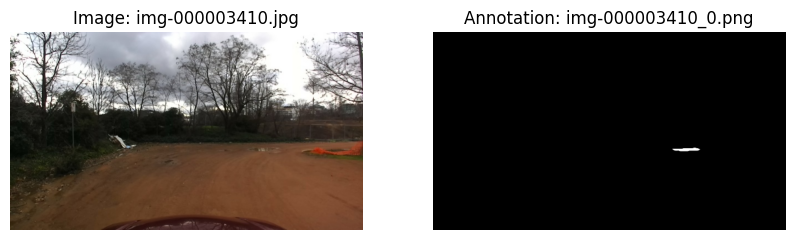

In [ ]:
load_image_and_annotation(class_id="7")

In [ ]:
import os

imgs_dir = "work/waterPuddle/imgs"
annotations_dir = "work/waterPuddle/annotations"

print(f"{'Class':<6} | {'Images':<6} | {'Annotations':<11}")
print("-" * 32)

for class_id in sorted(os.listdir(imgs_dir)):
    class_img_path = os.path.join(imgs_dir, class_id)
    class_ann_path = os.path.join(annotations_dir, class_id)

    if not os.path.isdir(class_img_path):
        continue

    num_imgs = len([f for f in os.listdir(class_img_path) if f.endswith(('.jpg', '.png'))])
    num_anns = len([f for f in os.listdir(class_ann_path) if f.endswith('.png')]) if os.path.exists(class_ann_path) else 0

    print(f"{class_id:<6} | {num_imgs:<6} | {num_anns:<11}")


Class  | Images | Annotations
--------------------------------
1      | 500    | 793        
2      | 500    | 959        
3      | 500    | 796        
4      | 500    | 287        
5      | 499    | 1813       
6      | 486    | 1378       
7      | 469    | 1203       


In [ ]:
!ls train/annotations/ | wc -l

ls: cannot access 'train/annotations/': No such file or directory
0


In [ ]:
extracted_path = "work/"
train_path = "work/train"
test_path = "work/test"

In [ ]:
os.makedirs(train_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)
os.makedirs(os.path.join(train_path,"imgs"), exist_ok=True)
os.makedirs(os.path.join(train_path,"annotations"),  exist_ok=True)
os.makedirs(os.path.join(test_path,"imgs"),  exist_ok=True)
os.makedirs(os.path.join(test_path,"annotations"),  exist_ok=True)

In [ ]:
import os
import random
import shutil
import cv2 as cv

# List all subdirectories in 'imgs' directory
img_subfolders = [f for f in os.listdir(os.path.join(extracted_path, 'waterPuddle/imgs')) if os.path.isdir(os.path.join(extracted_path, 'waterPuddle/imgs', f))]

# Iterate over each subfolder
for subfolder in img_subfolders:
    subfolder_path = os.path.join(extracted_path, 'waterPuddle/imgs', subfolder)
    print("subfolder_path",subfolder_path)
    # List all image files in the current subfolder
    imgs_files = [f for f in os.listdir(subfolder_path) if (f.endswith('.jpg') or f.endswith('.png'))]
    # Shuffle the files for randomness before splitting
    random.shuffle(imgs_files)
    print('all images',len(imgs_files))
    # Split the data
    split_index = int(0.8 * len(imgs_files))
    train_imgs = imgs_files[:split_index]
    test_imgs = imgs_files[split_index:]
    print('train_imgs',len(train_imgs))
    print('test_imgs',len(test_imgs))

    # Merge masks and move files to train folder
    for img in train_imgs:
      if img.endswith('.jpg'):
        annotation_file = os.path.join(extracted_path, 'waterPuddle/annotations', subfolder, img.replace('.jpg', '_0.png'))
      elif img.endswith('.png'):
        annotation_file = os.path.join(extracted_path, 'waterPuddle/annotations', subfolder, img.replace('.png', '_0.png'))
      i = 0 #index of annotation
      # Check if the annotation file exist
      print('img',img)
      label_path = annotation_file
      print('annotation_file',annotation_file)

      while os.path.exists(label_path):
        print('label_path',label_path)

        label_path = "%s_%d.png" % (annotation_file.rsplit("_0")[0],i+1)
        if i == 0 and os.path.exists(label_path):
          print('first mask')
          mask = cv.imread(annotation_file,1)
          i = i +1
        elif i != 0 and os.path.exists(label_path) :
          print(f'{i}th mask')
          label = cv.imread(label_path,1)
          mask = cv.bitwise_or(label, mask)
          i = i +1
        elif i== 0 and not os.path.exists(label_path):
          print('only one mask')
          mask = cv.imread(annotation_file,1)
          img_path = os.path.join(train_path, 'imgs', img)
          shutil.move(os.path.join(subfolder_path, img), img_path)
          img = img.rsplit('.')[0]
          print('img',img)
          annotations_path = os.path.join(train_path, 'annotations', img+'.png')
          print("img_path",img_path)
          print("annotations_path",annotations_path)
          cv.imwrite(annotations_path,mask)
          print('saved-train')

        elif i!=0 and not os.path.exists(label_path) :
          img_path = os.path.join(train_path, 'imgs', img)
          shutil.move(os.path.join(subfolder_path, img), img_path)
          img = img.rsplit('.')[0]
          print('img',img)
          annotations_path = os.path.join(train_path, 'annotations', img+'.png')
          print("img_path",img_path)
          print("annotations_path",annotations_path)
          cv.imwrite(annotations_path,mask)
          print('saved-train')


    # Merge masks and move files to train folder
    for img in test_imgs:
      if img.endswith('.jpg'):
        annotation_file = os.path.join(extracted_path, 'waterPuddle/annotations', subfolder, img.replace('.jpg', '_0.png'))
      elif img.endswith('.png'):
        annotation_file = os.path.join(extracted_path, 'waterPuddle/annotations', subfolder, img.replace('.png', '_0.png'))
      i = 0 #index of annotation
      # Check if the annotation file exist
      print('img',img)
      label_path = annotation_file
      print('annotation_file',annotation_file)

      while os.path.exists(label_path):
        print('label_path',label_path)

        label_path = "%s_%d.png" % (annotation_file.rsplit("_0")[0],i+1)
        if i == 0 and os.path.exists(label_path):
          print('first mask')
          mask = cv.imread(annotation_file,1)
          i = i +1
        elif i != 0 and os.path.exists(label_path) :
          print(f'{i}th mask')
          label = cv.imread(label_path,1)
          mask = cv.bitwise_or(label, mask)
          i = i +1
        elif i== 0 and not os.path.exists(label_path):
          print('only one mask')
          mask = cv.imread(annotation_file,1)
          img_path = os.path.join(test_path, 'imgs', img)
          shutil.move(os.path.join(subfolder_path, img), img_path)
          img = img.rsplit('.')[0]
          print('img',img)
          annotations_path = os.path.join(test_path, 'annotations', img+'.png')
          print("img_path",img_path)
          print("annotations_path",annotations_path)
          cv.imwrite(annotations_path,mask)
          print('saved-test')

        elif i!=0 and not os.path.exists(label_path) :
          img_path = os.path.join(test_path, 'imgs', img)
          shutil.move(os.path.join(subfolder_path, img), img_path)
          img = img.rsplit('.')[0]
          print('img',img)
          annotations_path = os.path.join(test_path, 'annotations', img+'.png')
          print("img_path",img_path)
          print("annotations_path",annotations_path)
          cv.imwrite(annotations_path,mask)
          print('saved-test')

subfolder_path work/waterPuddle/imgs/3
all images 500
train_imgs 400
test_imgs 100
img 22091.jpg
annotation_file work/waterPuddle/annotations/3/22091_0.png
label_path work/waterPuddle/annotations/3/22091_0.png
first mask
label_path work/waterPuddle/annotations/3/22091_1.png
img 22091
img_path work/train/imgs/22091.jpg
annotations_path work/train/annotations/22091.png
saved-train
img 21092.jpg
annotation_file work/waterPuddle/annotations/3/21092_0.png
label_path work/waterPuddle/annotations/3/21092_0.png
only one mask
img 21092
img_path work/train/imgs/21092.jpg
annotations_path work/train/annotations/21092.png
saved-train
img 3105.jpg
annotation_file work/waterPuddle/annotations/3/3105_0.png
label_path work/waterPuddle/annotations/3/3105_0.png
first mask
label_path work/waterPuddle/annotations/3/3105_1.png
1th mask
label_path work/waterPuddle/annotations/3/3105_2.png
img 3105
img_path work/train/imgs/3105.jpg
annotations_path work/train/annotations/3105.png
saved-train
img 303.jpg
anno

##Augmentation

In [ ]:
!pip install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 97.6 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [albumentations]m [albumentations]eadless]


In [ ]:
import torchvision.transforms.functional as TF
img_height, img_width = 128, 128
batch_size = 32
num_epochs = 15

# img_height, img_width = 128, 128
# batch_size = 32
# num_epochs = 30

# class JointTransform:
#     def __init__(self, resize, hflip_prob, affine_params=None):
#         self.resize = resize
#         self.hflip_prob = hflip_prob
#         self.affine_params = affine_params

#     def __call__(self, img, mask):
#         # Resize
#         img = TF.resize(img, self.resize)
#         mask = TF.resize(mask, self.resize)

#         # Random horizontal flip
#         if torch.rand(1).item() < self.hflip_prob:
#             img = TF.hflip(img)
#             mask = TF.hflip(mask)

#         # Random affine
#         if self.affine_params:
#             angle = torch.empty(1).uniform_(-self.affine_params['degrees'], self.affine_params['degrees']).item()
#             translate = (int(self.affine_params['translate'][0] * self.resize[1]),
#                          int(self.affine_params['translate'][1] * self.resize[0]))
#             scale = torch.empty(1).uniform_(self.affine_params['scale'][0], self.affine_params['scale'][1]).item()
#             shear = [0.0, 0.0]

#             img = TF.affine(img, angle=angle, translate=translate, scale=scale, shear=shear)
#             mask = TF.affine(mask, angle=angle, translate=translate, scale=scale, shear=shear)

#         # Convert to tensor
#         img = TF.to_tensor(img)
#         mask = TF.to_tensor(mask)

#         return img, mask


import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import torch

class AlbumentationsJointTransform:
    def __init__(self, height, width, transform_list):
        self.transform = A.Compose(
            transform_list + [
                A.Resize(height, width),
                ToTensorV2(transpose_mask=True)
            ],
            additional_targets={'mask': 'mask'}
        )

    def __call__(self, img, mask):
        # PIL → Numpy
        img = np.array(img)
        mask = np.array(mask)

        # Apply joint transform
        augmented = self.transform(image=img, mask=mask)
        img_tensor = augmented['image'].float() /255.0       # float32
        mask_tensor = augmented['mask'].long()         # int64

        return img_tensor, mask_tensor.unsqueeze(0)



In [ ]:
# easy_transform = JointTransform(
#     resize=(128, 128),
#     hflip_prob=0.3,
#     affine_params=None
# )

# medium_transform = JointTransform(
#     resize=(128, 128),
#     hflip_prob=0.5,
#     affine_params=dict(degrees=15, translate=(0.05, 0.05), scale=(0.9, 1.1))
# )

# hard_transform = JointTransform(
#     resize=(128, 128),
#     hflip_prob=0.7,
#     affine_params=dict(degrees=30, translate=(0.1, 0.1), scale=(0.8, 1.2))
# )

# test_transform = JointTransform(
#     resize=(128, 128),
#     hflip_prob=0.0,
#     affine_params=None
# )


easy_transform = AlbumentationsJointTransform(
    height=128,
    width=128,
    transform_list=[
        A.HorizontalFlip(p=0.3),
    ]
)
medium_transform = AlbumentationsJointTransform(
    height=128,
    width=128,
    transform_list=[
        A.HorizontalFlip(p=0.5),
        A.Affine(rotate=(-15, 15), translate_percent=(0.05, 0.05), scale=(0.9, 1.1), p=0.7),
        A.RandomBrightnessContrast(p=0.5),
        A.ColorJitter(p=0.3),
        A.GaussianBlur(p=0.2),
        A.MotionBlur(p=0.2),
    ]
)
hard_transform = AlbumentationsJointTransform(
    height=128,
    width=128,
    transform_list=[
        A.HorizontalFlip(p=0.7),
        A.Affine(rotate=(-30, 30), translate_percent=(0.1, 0.1), scale=(0.8, 1.2), p=0.8),
        A.RandomBrightnessContrast(p=0.5),
        A.ColorJitter(p=0.5),
        A.GaussianBlur(p=0.3),
        A.MotionBlur(p=0.3),
        A.RandomFog(fog_coef_lower=0.2, fog_coef_upper=0.5, alpha_coef=0.1, p=0.2),
        A.CoarseDropout(max_holes=8, max_height=16, max_width=16, fill_value=0, p=0.5),
        A.Perspective(scale=(0.05, 0.1), p=0.3),
    ]
)
test_transform = AlbumentationsJointTransform(
    height=128,
    width=128,
    transform_list=[]
)


/tmp/ipykernel_2155/1247270873.py:55: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.2, fog_coef_upper=0.5, alpha_coef=0.1, p=0.2),
/tmp/ipykernel_2155/1247270873.py:56: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=16, max_width=16, fill_value=0, p=0.5),


In [ ]:
# class SegmentationDataset(Dataset):
#     def __init__(self, image_dir, mask_dir, image_transform=None, mask_transform=None):
#         self.image_dir = image_dir
#         self.mask_dir = mask_dir
#         self.image_transform = image_transform
#         self.mask_transform = mask_transform

#         self.images = sorted([f for f in os.listdir(image_dir)
#                             if f.endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))])

#         # Verify that masks exist for all images
#         self.valid_images = []
#         for img in self.images:
#             base_name = os.path.splitext(img)[0]
#             mask_exists = any(os.path.exists(os.path.join(mask_dir, base_name + ext))
#                             for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tiff'])
#             if mask_exists:
#                 self.valid_images.append(img)
#             else:
#                 print(f"Warning: No mask found for image {img}")

#         self.images = self.valid_images
#         print(f"Found {len(self.images)} valid image-mask pairs")

#     def __len__(self):
#         return len(self.images)

#     def __getitem__(self, idx):
#         # Set random seed for synchronized augmentations
#         seed = random.randint(0, 2**32)

#         # Load image
#         img_name = self.images[idx]
#         img_path = os.path.join(self.image_dir, img_name)
#         image = Image.open(img_path).convert('RGB')

#         # Load mask
#         base_name = os.path.splitext(img_name)[0]
#         mask = None
#         for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']:
#             mask_path = os.path.join(self.mask_dir, base_name + ext)
#             if os.path.exists(mask_path):
#                 mask = Image.open(mask_path).convert('L')  # Convert to grayscale
#                 break

#         if mask is None:
#             raise FileNotFoundError(f"Mask not found for {img_name}")

#         # Apply transforms with same random seed
#         if self.image_transform:
#             torch.manual_seed(seed)
#             image = self.image_transform(image)
#         if self.mask_transform:
#             torch.manual_seed(seed)
#             mask = self.mask_transform(mask)
#             # Ensure mask is float32 and in [0, 1] for binary masks
#             mask = mask.float()

#         return image, mask


from torch.utils.data import Dataset
from PIL import Image
import os
import torch

class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform  # فقط یک transform مشترک

        self.images = sorted([f for f in os.listdir(image_dir)
                              if f.endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))])

        self.valid_images = []
        for img in self.images:
            base_name = os.path.splitext(img)[0]
            mask_exists = any(os.path.exists(os.path.join(mask_dir, base_name + ext))
                              for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tiff'])
            if mask_exists:
                self.valid_images.append(img)
            else:
                print(f"Warning: No mask found for image {img}")

        self.images = self.valid_images
        print(f"Found {len(self.images)} valid image-mask pairs")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)

        image = Image.open(img_path).convert('RGB')

        base_name = os.path.splitext(img_name)[0]
        mask = None
        for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']:
            mask_path = os.path.join(self.mask_dir, base_name + ext)
            if os.path.exists(mask_path):
                mask = Image.open(mask_path).convert('L')
                break

        if mask is None:
            raise FileNotFoundError(f"Mask not found for {img_name}")

        # Apply joint transform (both image and mask simultaneously)
        if self.transform:
            image, mask = self.transform(image, mask)

        # Ensure mask is float tensor (0.0 or 1.0)
        mask = (mask > 0).float()

        return image, mask


#Setting the Train and Test data set with the suitable augmentation

In [ ]:
# # Assuming train_path and test_path are defined from your earlier code
# print("Loading training dataset...")
# train_dataset = SegmentationDataset(
#     image_dir=os.path.join(train_path, 'imgs'),
#     mask_dir=os.path.join(train_path, 'annotations'),
# )

# print("\nLoading test dataset...")
# test_dataset = SegmentationDataset(
#     image_dir=os.path.join(test_path, 'imgs'),
#     mask_dir=os.path.join(test_path, 'annotations'),
# )


print("Loading training dataset...")
train_medium_dataset = SegmentationDataset(
    image_dir=os.path.join(train_path, 'imgs'),
    mask_dir=os.path.join(train_path, 'annotations'),
    transform=hard_transform  # از JointTransform استفاده کن
)

print("Loading training dataset...")
train_hard_dataset = SegmentationDataset(
    image_dir=os.path.join(train_path, 'imgs'),
    mask_dir=os.path.join(train_path, 'annotations'),
    transform=medium_transform  # از JointTransform استفاده کن
)

print("\nLoading test dataset...")
test_dataset = SegmentationDataset(
    image_dir=os.path.join(test_path, 'imgs'),
    mask_dir=os.path.join(test_path, 'annotations'),
    transform=test_transform  # برای تست هم می‌تونه نسخه ساده باشه بدون تغییرات شدید
)


Loading training dataset...
Found 2764 valid image-mask pairs
Loading training dataset...
Found 2764 valid image-mask pairs

Loading test dataset...
Found 1044 valid image-mask pairs


In [ ]:
# train_loader = DataLoader(
#     train_dataset,
#     batch_size=batch_size,
#     shuffle=True,
#     num_workers=0,
#     pin_memory=True if torch.cuda.is_available() else False,
#     drop_last=False,
# )

# test_loader = DataLoader(
#     test_dataset,
#     batch_size=batch_size,
#     shuffle=False,
#     num_workers=0,
#     pin_memory=True if torch.cuda.is_available() else False,
#     drop_last=False
# )

train_medium_loader = DataLoader(
    train_medium_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=False,
)

train_hard_loader = DataLoader(
    train_hard_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=False
)

print(f"\nTraining batches medium: {len(train_medium_loader)}")
print(f"\nTraining batches hard: {len(train_hard_loader)}")
print(f"Test batches: {len(test_loader)}")

if len(train_medium_loader) > 0:
    images_m, masks_m = next(iter(train_medium_loader))
    print(f"\nSample batch shape:")
    print(f"Images: {images_m.shape} (dtype: {images_m.dtype}, range: [{images_m.min():.3f}, {images_m.max():.3f}])")
    print(f"Masks: {masks_m.shape} (dtype: {masks_m.dtype}, range: [{masks_m.min():.3f}, {masks_m.max():.3f}])")


Training batches medium: 87

Training batches hard: 87
Test batches: 33

Sample batch shape:
Images: torch.Size([32, 3, 128, 128]) (dtype: torch.float32, range: [0.000, 1.000])
Masks: torch.Size([32, 1, 128, 128]) (dtype: torch.float32, range: [0.000, 1.000])


In [ ]:
import torch
#import torch.nn.functional as F
import torchvision.transforms.functional as F


def iou(y_true, y_pred, smooth=100):
    """
    Calculate IoU using the same formula as Keras implementation.
    Note: This uses squared values in denominator which is non-standard for IoU.
    """
    # Ensure float tensors
    y_true = y_true.float()
    y_pred = y_pred.float()

    # Calculate intersection
    intersection = torch.sum(torch.abs(y_true * y_pred), dim=-1)

    # Calculate sum of squares
    sum_ = torch.sum(torch.square(y_true), dim=-1) + torch.sum(torch.square(y_pred), dim=-1)

    # Calculate IoU
    jac = (intersection + smooth) / (sum_ - intersection + smooth)

    return jac

def dice_coef(y_true, y_pred, smooth=100):
    """
    Calculate Dice coefficient exactly as in Keras implementation.
    """
    # Flatten the tensors
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()

    # Calculate intersection
    intersection = torch.sum(y_true_f * y_pred_f)

    # Calculate Dice coefficient
    return (2. * intersection + smooth) / (torch.sum(y_true_f) + torch.sum(y_pred_f) + smooth)

def precision(y_true, y_pred):
    """
    Calculate precision exactly as in Keras implementation.
    """
    # Clip values between 0 and 1, then round
    true_positives = torch.sum(torch.round(torch.clamp(y_true * y_pred, 0, 1)))
    predicted_positives = torch.sum(torch.round(torch.clamp(y_pred, 0, 1)))

    # Calculate precision with epsilon to avoid division by zero
    precision_value = true_positives / (predicted_positives + 1e-7)

    return precision_value

def recall(y_true, y_pred):
    """
    Calculate recall exactly as in Keras implementation.
    """
    # Clip values between 0 and 1, then round
    true_positives = torch.sum(torch.round(torch.clamp(y_true * y_pred, 0, 1)))
    possible_positives = torch.sum(torch.round(torch.clamp(y_true, 0, 1)))

    # Calculate recall with epsilon to avoid division by zero
    recall_value = true_positives / (possible_positives + 1e-7)

    return recall_value

def accuracy(y_true, y_pred):
    """
    Calculate accuracy exactly as in Keras implementation.
    """
    # Round predictions and compare with true values
    return torch.mean((y_true == torch.round(y_pred)).float())

def jaccard_distance(y_true, y_pred, smooth=100):
    """
    Calculate Jaccard distance (1 - IoU) exactly as in Keras implementation.
    """
    # Cast to float32
    y_true = y_true.float()
    y_pred = y_pred.float()

    # Calculate intersection
    intersection = torch.sum(torch.abs(y_true * y_pred), dim=-1)

    # Calculate sum of squares
    sum_ = torch.sum(torch.square(y_true), dim=-1) + torch.sum(torch.square(y_pred), dim=-1)

    # Calculate Jaccard index
    jac = (intersection + smooth) / (sum_ - intersection + smooth)

    # Return Jaccard distance
    return 1 - jac

In [ ]:
def visualize_samples(loader, num_samples=4, title="Samples"):
    """Visualize a few samples from the DataLoader to check augmentations."""
    images, masks = next(iter(loader))
    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples * 3, 6))
    for i in range(min(num_samples, len(images))):
        # Convert tensor to numpy for visualization
        img = images[i].permute(1, 2, 0).numpy()  # [C, H, W] -> [H, W, C]
        msk = masks[i].squeeze().numpy()  # [1, H, W] -> [H, W]

        # Plot image
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"Image {i+1}")
        axes[0, i].axis('off')

        # Plot mask
        axes[1, i].imshow(msk, cmap='gray')
        axes[1, i].set_title(f"Mask {i+1}")
        axes[1, i].axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


Sample batch shape:
Images: torch.Size([32, 3, 128, 128]) (dtype: torch.float32, range: [0.000, 1.000])
Masks: torch.Size([32, 1, 128, 128]) (dtype: torch.float32, range: [0.000, 1.000])


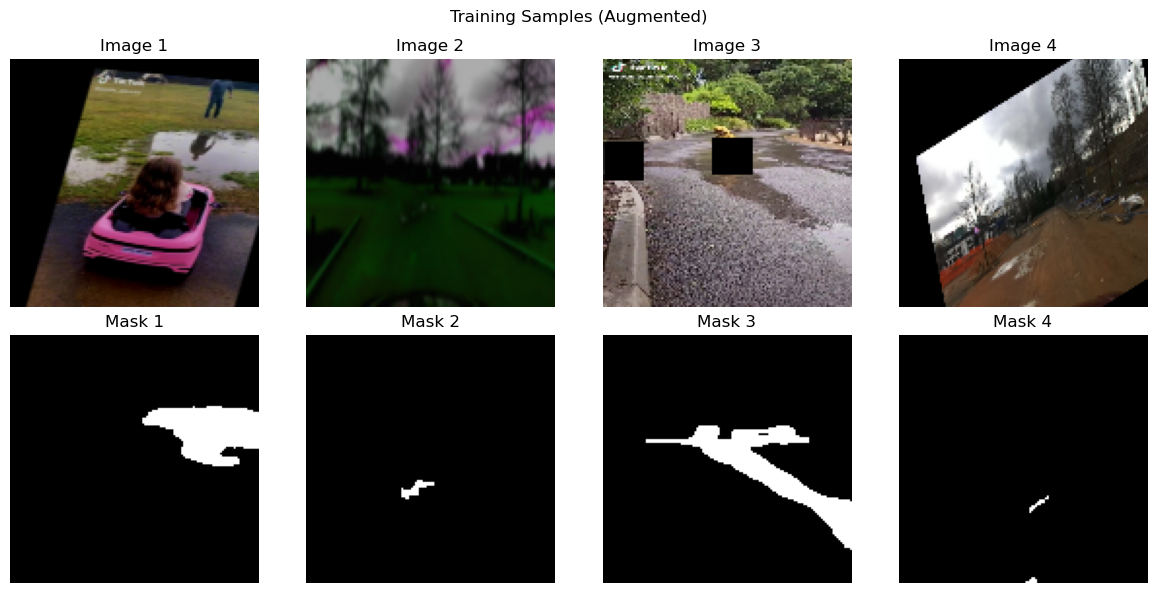

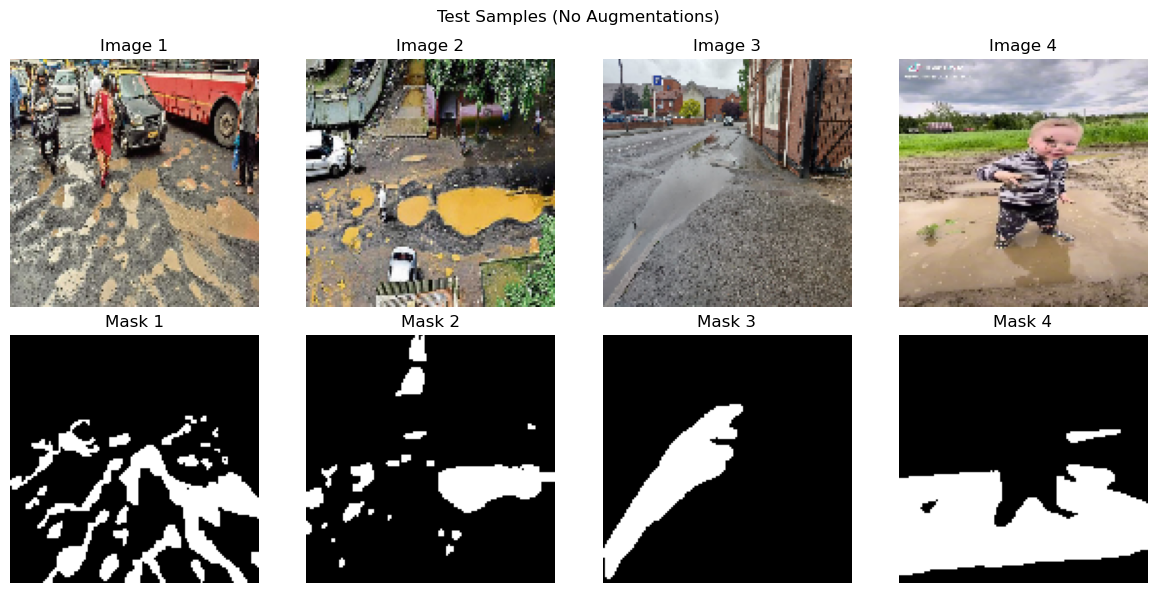

In [ ]:
if len(train_medium_loader) > 0:
    images, masks = next(iter(train_medium_loader))
    print(f"\nSample batch shape:")
    print(f"Images: {images.shape} (dtype: {images.dtype}, range: [{images.min():.3f}, {images.max():.3f}])")
    print(f"Masks: {masks.shape} (dtype: {masks.dtype}, range: [{masks.min():.3f}, {masks.max():.3f}])")

    # Visualize training samples to check augmentations
    visualize_samples(train_medium_loader, num_samples=4, title="Training Samples (Augmented)")

if len(test_loader) > 0:
    # Visualize test samples to compare (no augmentations)
    visualize_samples(test_loader, num_samples=4, title="Test Samples (No Augmentations)")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

class ASPP(nn.Module):
    """Atrous Spatial Pyramid Pooling"""
    def __init__(self, in_channels, out_channels=256):
        super(ASPP, self).__init__()

        # Different dilation rates
        dilations = [1, 6, 12, 18]

        self.aspp1 = nn.Conv2d(in_channels, out_channels, 1, bias=False)
        self.aspp2 = nn.Conv2d(in_channels, out_channels, 3, padding=dilations[1], dilation=dilations[1], bias=False)
        self.aspp3 = nn.Conv2d(in_channels, out_channels, 3, padding=dilations[2], dilation=dilations[2], bias=False)
        self.aspp4 = nn.Conv2d(in_channels, out_channels, 3, padding=dilations[3], dilation=dilations[3], bias=False)

        self.global_avg_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.conv1 = nn.Conv2d(out_channels * 5, out_channels, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.5)

        # Initialize batch norm for aspp layers
        for m in [self.aspp1, self.aspp2, self.aspp3, self.aspp4]:
            nn.init.kaiming_normal_(m.weight)

    def forward(self, x):
        x1 = self.aspp1(x)
        x2 = self.aspp2(x)
        x3 = self.aspp3(x)
        x4 = self.aspp4(x)
        x5 = self.global_avg_pool(x)
        x5 = F.interpolate(x5, size=x4.size()[2:], mode='bilinear', align_corners=True)

        x = torch.cat((x1, x2, x3, x4, x5), dim=1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        return x

# class DeepLabV3Plus(nn.Module):
#     def __init__(self, num_classes=1, backbone='resnet50'):
#         super(DeepLabV3Plus, self).__init__()

#         # Backbone
#         if backbone == 'resnet50':
#             self.backbone = models.resnet50(pretrained=True)
#             low_level_channels = 256
#             high_level_channels = 2048
#         elif backbone == 'resnet18':
#             self.backbone = models.resnet18(pretrained=True)
#             low_level_channels = 64
#             high_level_channels = 512
#         else:
#             raise ValueError("Backbone not supported")

#         # Remove avgpool and fc layers
#         self.backbone = nn.Sequential(*list(self.backbone.children())[:-2])

#         # ASPP
#         self.aspp = ASPP(high_level_channels)

#         # Decoder
#         self.reduce_conv = nn.Sequential(
#             nn.Conv2d(low_level_channels, 48, 1, bias=False),
#             nn.BatchNorm2d(48),
#             nn.ReLU(inplace=True)
#         )

#         self.decoder = nn.Sequential(
#             nn.Conv2d(256 + 48, 256, 3, padding=1, bias=False),
#             nn.BatchNorm2d(256),
#             nn.ReLU(inplace=True),
#             nn.Dropout(0.5),
#             nn.Conv2d(256, 256, 3, padding=1, bias=False),
#             nn.BatchNorm2d(256),
#             nn.ReLU(inplace=True),
#             nn.Dropout(0.1)
#         )

#         self.classifier = nn.Conv2d(256, num_classes, 1)

#     def forward(self, x):
#         input_shape = x.shape[-2:]

#         # Extract features
#         features = []
#         for i, layer in enumerate(self.backbone):
#             x = layer(x)
#             if i == 4:  # After layer1 (low-level features)
#                 low_level_feat = x
#             features.append(x)

#         # High-level features through ASPP
#         high_level_feat = self.aspp(x)

#         # Upsample high-level features
#         high_level_feat = F.interpolate(high_level_feat, size=low_level_feat.shape[-2:],
#                                       mode='bilinear', align_corners=True)

#         # Reduce low-level feature channels
#         low_level_feat = self.reduce_conv(low_level_feat)

#         # Concatenate features
#         concat_feat = torch.cat([high_level_feat, low_level_feat], dim=1)

#         # Decode
#         out = self.decoder(concat_feat)
#         out = self.classifier(out)

#         # Upsample to input size
#         out = F.interpolate(out, size=input_shape, mode='bilinear', align_corners=True)

#         return torch.sigmoid(out)

#Adding attention to the model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

# ---------------------- CBAM Module ---------------------- #
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=8):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.shared_MLP = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.shared_MLP(self.avg_pool(x))
        max_out = self.shared_MLP(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        concat = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(concat))


class CBAM(nn.Module):
    def __init__(self, channels, ratio=8, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(channels, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

# ---------------------- DeepLabV3Plus Model ---------------------- #
class DeepLabV3Plus(nn.Module):
    def __init__(self, num_classes=1, backbone='resnet50'):
        super(DeepLabV3Plus, self).__init__()

        # Backbone
        if backbone == 'resnet50':
            self.backbone = models.resnet50(pretrained=True)
            low_level_channels = 256
            high_level_channels = 2048
        elif backbone == 'resnet18':
            self.backbone = models.resnet18(pretrained=True)
            low_level_channels = 64
            high_level_channels = 512
        else:
            raise ValueError("Backbone not supported")

        # Remove avgpool and fc layers
        self.backbone = nn.Sequential(*list(self.backbone.children())[:-2])

        # ASPP
        self.aspp = ASPP(high_level_channels)

        # Attention block after ASPP
        self.attention = CBAM(256)

        # Reduce low-level features
        self.reduce_conv = nn.Sequential(
            nn.Conv2d(low_level_channels, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(256 + 48, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1)
        )

        # Final classifier
        self.classifier = nn.Conv2d(256, num_classes, 1)

    def forward(self, x):
        input_shape = x.shape[-2:]

        # Extract features
        for i, layer in enumerate(self.backbone):
            x = layer(x)
            if i == 4:  # After layer1 (low-level features)
                low_level_feat = x

        # ASPP on high-level features
        high_level_feat = self.aspp(x)

        # Apply CBAM attention
        high_level_feat = self.attention(high_level_feat)

        # Upsample high-level to low-level feature size
        high_level_feat = F.interpolate(high_level_feat, size=low_level_feat.shape[-2:], mode='bilinear', align_corners=True)

        # Reduce low-level features
        low_level_feat = self.reduce_conv(low_level_feat)

        # Concatenate
        concat_feat = torch.cat([high_level_feat, low_level_feat], dim=1)

        # Decode and classify
        out = self.decoder(concat_feat)
        out = self.classifier(out)

        # Final upsample to input size
        out = F.interpolate(out, size=input_shape, mode='bilinear', align_corners=True)

        return torch.sigmoid(out)


#Using DeepLabV3+

In [ ]:
# # Initialize DeepLabV3+
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepLabV3Plus(num_classes=1, backbone='resnet18').to(device)  # Use resnet18 for faster training
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters")

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100% 44.7M/44.7M [00:00<00:00, 107MB/s] 


Model has 16,617,475 trainable parameters


In [ ]:
# Function to calculate all metrics
def calculate_all_metrics(y_true, y_pred):
    """Calculate all metrics for a batch"""
    metrics = {}

    # Convert to binary predictions
    y_pred_binary = (y_pred > 0.5).float()

    # Calculate each metric
    metrics['iou'] = iou(y_true, y_pred_binary).mean().item()
    metrics['dice'] = dice_coef(y_true, y_pred_binary).item()
    metrics['precision'] = precision(y_true, y_pred_binary).item()
    metrics['recall'] = recall(y_true, y_pred_binary).item()
    metrics['accuracy'] = accuracy(y_true, y_pred_binary).item()
    metrics['jaccard_distance'] = jaccard_distance(y_true, y_pred_binary).mean().item()

    return metrics

def validate_model():
    """Comprehensive validation with all metrics"""
    model.eval()

    # Initialize metric accumulators
    total_metrics = {
        'iou': 0,
        'dice': 0,
        'precision': 0,
        'recall': 0,
        'accuracy': 0,
        'jaccard_distance': 0,
        'loss': 0
    }

    num_batches = 0

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, masks)
            total_metrics['loss'] += loss.item()

            # Calculate all metrics
            batch_metrics = calculate_all_metrics(masks, outputs)

            # Accumulate metrics
            for key, value in batch_metrics.items():
                total_metrics[key] += value

            num_batches += 1

    # Calculate averages
    avg_metrics = {key: value / num_batches for key, value in total_metrics.items()}

    # Print results
    print("\n" + "="*50)
    print("VALIDATION RESULTS:")
    print("="*50)
    print(f"Loss:              {avg_metrics['loss']:.4f}")
    print(f"IoU:               {avg_metrics['iou']:.4f}")
    print(f"Dice Coefficient:  {avg_metrics['dice']:.4f}")
    print(f"Precision:         {avg_metrics['precision']:.4f}")
    print(f"Recall:            {avg_metrics['recall']:.4f}")
    print(f"Accuracy:          {avg_metrics['accuracy']:.4f}")
    print(f"Jaccard Distance:  {avg_metrics['jaccard_distance']:.4f}")
    print("="*50 + "\n")

    model.train()
    return avg_metrics

def train_model_curriculum():
    """Training loop with comprehensive metric tracking"""
    best_dice = 0.0
    num_epochs = 15

    print("training medium model on 15 epochs")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        epoch_metrics = {
            'iou': 0,
            'dice': 0,
            'precision': 0,
            'recall': 0,
            'accuracy': 0,
            'jaccard_distance': 0
        }

        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        for batch_idx, (images, masks) in enumerate(train_medium_loader):
            images = images.to(device)
            masks = masks.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Calculate metrics for this batch
            with torch.no_grad():
                batch_metrics = calculate_all_metrics(masks, outputs)
                for key, value in batch_metrics.items():
                    epoch_metrics[key] += value

            # Print progress every 20 batches
            if batch_idx % 20 == 0:
                print(f'Batch {batch_idx:3d}/{len(train_medium_loader)} | Loss: {loss.item():.4f} | '
                      f'IoU: {batch_metrics["iou"]:.3f} | Dice: {batch_metrics["dice"]:.3f}')

        # Calculate epoch averages
        avg_loss = running_loss / len(train_medium_loader)
        avg_epoch_metrics = {key: value / len(train_medium_loader) for key, value in epoch_metrics.items()}

        print(f'\nEpoch {epoch+1} Training Results:')
        print(f'Average Loss: {avg_loss:.4f}')
        print(f'Average IoU: {avg_epoch_metrics["iou"]:.4f}')
        print(f'Average Dice: {avg_epoch_metrics["dice"]:.4f}')
        print(f'Average Precision: {avg_epoch_metrics["precision"]:.4f}')
        print(f'Average Recall: {avg_epoch_metrics["recall"]:.4f}')
        print(f'Average Accuracy: {avg_epoch_metrics["accuracy"]:.4f}')

        # Validation every 2 epochs
        if epoch % 2 == 0 or epoch == num_epochs - 1:
            val_metrics = validate_model()

            # Save best model based on Dice score
            if val_metrics['dice'] > best_dice:
                best_dice = val_metrics['dice']
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'dice_score': best_dice,
                    'all_metrics': val_metrics
                }, 'best_unet_model.pth')
                print(f"✓ New best model saved with Dice score: {best_dice:.4f}")

    print("training hard model on 15 epochs")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        epoch_metrics = {
            'iou': 0,
            'dice': 0,
            'precision': 0,
            'recall': 0,
            'accuracy': 0,
            'jaccard_distance': 0
        }

        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        for batch_idx, (images, masks) in enumerate(train_hard_loader):
            images = images.to(device)
            masks = masks.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Calculate metrics for this batch
            with torch.no_grad():
                batch_metrics = calculate_all_metrics(masks, outputs)
                for key, value in batch_metrics.items():
                    epoch_metrics[key] += value

            # Print progress every 20 batches
            if batch_idx % 20 == 0:
                print(f'Batch {batch_idx:3d}/{len(train_hard_loader)} | Loss: {loss.item():.4f} | '
                      f'IoU: {batch_metrics["iou"]:.3f} | Dice: {batch_metrics["dice"]:.3f}')

        # Calculate epoch averages
        avg_loss = running_loss / len(train_hard_loader)
        avg_epoch_metrics = {key: value / len(train_hard_loader) for key, value in epoch_metrics.items()}

        print(f'\nEpoch {epoch+1} Training Results:')
        print(f'Average Loss: {avg_loss:.4f}')
        print(f'Average IoU: {avg_epoch_metrics["iou"]:.4f}')
        print(f'Average Dice: {avg_epoch_metrics["dice"]:.4f}')
        print(f'Average Precision: {avg_epoch_metrics["precision"]:.4f}')
        print(f'Average Recall: {avg_epoch_metrics["recall"]:.4f}')
        print(f'Average Accuracy: {avg_epoch_metrics["accuracy"]:.4f}')

        # Validation every 2 epochs
        if epoch % 2 == 0 or epoch == num_epochs - 1:
            val_metrics = validate_model()

            # Save best model based on Dice score
            if val_metrics['dice'] > best_dice:
                best_dice = val_metrics['dice']
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'dice_score': best_dice,
                    'all_metrics': val_metrics
                }, 'best_unet_model.pth')
                print(f"✓ New best model saved with Dice score: {best_dice:.4f}")

def evaluate_final_model():
    """Final comprehensive evaluation"""
    print("\n" + "="*60)
    print("FINAL MODEL EVALUATION")
    print("="*60)

    # Load best model if it exists
    try:
        checkpoint = torch.load('best_unet_model.pth')
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded best model from epoch {checkpoint['epoch']} with Dice: {checkpoint['dice_score']:.4f}")
    except:
        print("Using current model weights for evaluation")

    # Run final validation
    final_metrics = validate_model()

    return final_metrics

In [ ]:
def train_model_only_medium():
    """Training loop with comprehensive metric tracking"""
    best_dice = 0.0
    num_epochs = 30

    print("training medium model on 30 epochs")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        epoch_metrics = {
            'iou': 0,
            'dice': 0,
            'precision': 0,
            'recall': 0,
            'accuracy': 0,
            'jaccard_distance': 0
        }

        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        for batch_idx, (images, masks) in enumerate(train_medium_loader):
            images = images.to(device)
            masks = masks.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Calculate metrics for this batch
            with torch.no_grad():
                batch_metrics = calculate_all_metrics(masks, outputs)
                for key, value in batch_metrics.items():
                    epoch_metrics[key] += value

            # Print progress every 20 batches
            if batch_idx % 20 == 0:
                print(f'Batch {batch_idx:3d}/{len(train_medium_loader)} | Loss: {loss.item():.4f} | '
                      f'IoU: {batch_metrics["iou"]:.3f} | Dice: {batch_metrics["dice"]:.3f}')

        # Calculate epoch averages
        avg_loss = running_loss / len(train_medium_loader)
        avg_epoch_metrics = {key: value / len(train_medium_loader) for key, value in epoch_metrics.items()}

        print(f'\nEpoch {epoch+1} Training Results:')
        print(f'Average Loss: {avg_loss:.4f}')
        print(f'Average IoU: {avg_epoch_metrics["iou"]:.4f}')
        print(f'Average Dice: {avg_epoch_metrics["dice"]:.4f}')
        print(f'Average Precision: {avg_epoch_metrics["precision"]:.4f}')
        print(f'Average Recall: {avg_epoch_metrics["recall"]:.4f}')
        print(f'Average Accuracy: {avg_epoch_metrics["accuracy"]:.4f}')

        # Validation every 2 epochs
        if epoch % 2 == 0 or epoch == num_epochs - 1:
            val_metrics = validate_model()

            # Save best model based on Dice score
            if val_metrics['dice'] > best_dice:
                best_dice = val_metrics['dice']
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'dice_score': best_dice,
                    'all_metrics': val_metrics
                }, 'best_unet_model.pth')
                print(f"✓ New best model saved with Dice score: {best_dice:.4f}")

In [ ]:
def train_model_only_hard():
    """Training loop with comprehensive metric tracking"""
    best_dice = 0.0
    num_epochs = 30

    print("training hard model on 30 epochs")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        epoch_metrics = {
            'iou': 0,
            'dice': 0,
            'precision': 0,
            'recall': 0,
            'accuracy': 0,
            'jaccard_distance': 0
        }

        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        for batch_idx, (images, masks) in enumerate(train_hard_loader):
            images = images.to(device)
            masks = masks.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Calculate metrics for this batch
            with torch.no_grad():
                batch_metrics = calculate_all_metrics(masks, outputs)
                for key, value in batch_metrics.items():
                    epoch_metrics[key] += value

            # Print progress every 20 batches
            if batch_idx % 20 == 0:
                print(f'Batch {batch_idx:3d}/{len(train_hard_loader)} | Loss: {loss.item():.4f} | '
                      f'IoU: {batch_metrics["iou"]:.3f} | Dice: {batch_metrics["dice"]:.3f}')

        # Calculate epoch averages
        avg_loss = running_loss / len(train_hard_loader)
        avg_epoch_metrics = {key: value / len(train_hard_loader) for key, value in epoch_metrics.items()}

        print(f'\nEpoch {epoch+1} Training Results:')
        print(f'Average Loss: {avg_loss:.4f}')
        print(f'Average IoU: {avg_epoch_metrics["iou"]:.4f}')
        print(f'Average Dice: {avg_epoch_metrics["dice"]:.4f}')
        print(f'Average Precision: {avg_epoch_metrics["precision"]:.4f}')
        print(f'Average Recall: {avg_epoch_metrics["recall"]:.4f}')
        print(f'Average Accuracy: {avg_epoch_metrics["accuracy"]:.4f}')

        # Validation every 2 epochs
        if epoch % 2 == 0 or epoch == num_epochs - 1:
            val_metrics = validate_model()

            # Save best model based on Dice score
            if val_metrics['dice'] > best_dice:
                best_dice = val_metrics['dice']
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'dice_score': best_dice,
                    'all_metrics': val_metrics
                }, 'best_unet_model.pth')
                print(f"✓ New best model saved with Dice score: {best_dice:.4f}")

#Train Model

In [ ]:
import matplotlib.pyplot as plt

def plot_comparison(histories, metric):
    epochs = range(1, len(histories['curriculum'][metric]) + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, histories['curriculum'][metric], label='Curriculum')
    plt.plot(epochs, histories['medium'][metric], label='Only Medium')
    plt.plot(epochs, histories['hard'][metric], label='Only Hard')
    plt.title(f'{metric.capitalize()} over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()

# After training all variants
histories = {
    'curriculum': train_model_curriculum(),
    'medium': train_model_only_medium(),
    'hard': train_model_only_hard()
}
plot_comparison(histories, 'loss')
plot_comparison(histories, 'iou')
plot_comparison(histories, 'dice')
# Repeat for precision, recall, accuracy

In [ ]:
train_model_curriculum()

final_results = evaluate_final_model()

print("\nTraining completed!")
print(f"Final Results Summary:")
for metric, value in final_results.items():
    print(f"{metric.capitalize()}: {value:.4f}")

training medium model on 15 epochs

Epoch 1/15
------------------------------
Batch   0/87 | Loss: 0.6243 | IoU: 0.774 | Dice: 0.100
Batch  20/87 | Loss: 0.5264 | IoU: 0.851 | Dice: 0.313
Batch  40/87 | Loss: 0.4292 | IoU: 0.902 | Dice: 0.491
Batch  60/87 | Loss: 0.3468 | IoU: 0.941 | Dice: 0.612
Batch  80/87 | Loss: 0.3017 | IoU: 0.948 | Dice: 0.532

Epoch 1 Training Results:
Average Loss: 0.4396
Average IoU: 0.8916
Average Dice: 0.3917
Average Precision: 0.3511
Average Recall: 0.5136
Average Accuracy: 0.8649

VALIDATION RESULTS:
Loss:              0.4809
IoU:               0.9190
Dice Coefficient:  0.4323
Precision:         0.3875
Recall:            0.5655
Accuracy:          0.8880
Jaccard Distance:  0.0810

✓ New best model saved with Dice score: 0.4323

Epoch 2/15
------------------------------
Batch   0/87 | Loss: 0.2790 | IoU: 0.951 | Dice: 0.657
Batch  20/87 | Loss: 0.2945 | IoU: 0.949 | Dice: 0.373
Batch  40/87 | Loss: 0.2328 | IoU: 0.951 | Dice: 0.300
Batch  60/87 | Loss: 0.26

In [ ]:
import torch
import json
import os
from datetime import datetime

def test_model(model, test_loader, device, model_path=None, save_results=True):
    """Comprehensive testing with all metrics and detailed analysis"""

    # Load model if path provided
    if model_path and os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✓ Loaded model from {model_path}")
        if 'epoch' in checkpoint:
            print(f"  Model was saved at epoch {checkpoint['epoch']}")
        if 'dice_score' in checkpoint:
            print(f"  Training Dice score: {checkpoint['dice_score']:.4f}")
    else:
        print("Using current model weights for testing")

    model.eval()

    # Initialize metric accumulators
    total_metrics = {
        'iou': 0,
        'dice': 0,
        'precision': 0,
        'recall': 0,
        'accuracy': 0,
        'jaccard_distance': 0,
        'loss': 0
    }

    # For per-batch analysis
    batch_metrics = []
    num_batches = 0
    total_samples = 0

    # Loss function for testing
    criterion = torch.nn.BCELoss()

    print("\n" + "="*60)
    print("RUNNING COMPREHENSIVE TEST EVALUATION")
    print("="*60)

    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(test_loader):
            images = images.to(device)
            masks = masks.to(device)
            batch_size = images.size(0)
            total_samples += batch_size

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, masks)
            total_metrics['loss'] += loss.item()

            # Calculate all metrics for this batch
            batch_metric_values = calculate_all_metrics(masks, outputs)
            batch_metric_values['loss'] = loss.item()
            batch_metric_values['batch_size'] = batch_size
            batch_metrics.append(batch_metric_values)

            # Accumulate metrics
            for key, value in batch_metric_values.items():
                if key not in ['batch_size']:
                    total_metrics[key] += value

            num_batches += 1

            # Print progress every 5 batches
            if batch_idx % 5 == 0:
                print(f"Processed batch {batch_idx+1}/{len(test_loader)} "
                      f"({total_samples} samples) | "
                      f"IoU: {batch_metric_values['iou']:.3f} | "
                      f"Dice: {batch_metric_values['dice']:.3f}")

    # Calculate final averages
    avg_metrics = {key: value / num_batches for key, value in total_metrics.items()}

    # Calculate standard deviations
    std_metrics = {}
    for metric in ['iou', 'dice', 'precision', 'recall', 'accuracy', 'jaccard_distance', 'loss']:
        values = [batch[metric] for batch in batch_metrics]
        mean_val = sum(values) / len(values)
        variance = sum((x - mean_val) ** 2 for x in values) / len(values)
        std_metrics[metric] = variance ** 0.5

    # Print comprehensive test results
    print("\n" + "="*60)
    print("FINAL TEST RESULTS")
    print("="*60)
    print(f"Total test samples: {total_samples}")
    print(f"Total test batches: {num_batches}")
    print("-" * 60)
    print(f"{'Metric':<20} {'Mean':<10} {'Std':<10} {'Range'}")
    print("-" * 60)

    for metric in ['loss', 'iou', 'dice', 'precision', 'recall', 'accuracy', 'jaccard_distance']:
        values = [batch[metric] for batch in batch_metrics]
        min_val = min(values)
        max_val = max(values)
        print(f"{metric.capitalize():<20} {avg_metrics[metric]:<10.4f} {std_metrics[metric]:<10.4f} [{min_val:.3f}, {max_val:.3f}]")

    print("=" * 60)

    # Additional analysis
    print("\nDETAILED ANALYSIS:")
    print("-" * 30)

    # Best and worst performing batches
    dice_values = [batch['dice'] for batch in batch_metrics]
    best_batch_idx = dice_values.index(max(dice_values))
    worst_batch_idx = dice_values.index(min(dice_values))

    print(f"Best performing batch:  #{best_batch_idx+1} (Dice: {max(dice_values):.4f})")
    print(f"Worst performing batch: #{worst_batch_idx+1} (Dice: {min(dice_values):.4f})")

    # Performance distribution
    excellent = sum(1 for d in dice_values if d > 0.8)
    good = sum(1 for d in dice_values if 0.6 < d <= 0.8)
    fair = sum(1 for d in dice_values if 0.4 < d <= 0.6)
    poor = sum(1 for d in dice_values if d <= 0.4)

    print(f"\nPerformance distribution (by Dice score):")
    print(f"  Excellent (>0.8):     {excellent:3d} batches ({excellent/num_batches*100:.1f}%)")
    print(f"  Good (0.6-0.8):       {good:3d} batches ({good/num_batches*100:.1f}%)")
    print(f"  Fair (0.4-0.6):       {fair:3d} batches ({fair/num_batches*100:.1f}%)")
    print(f"  Poor (≤0.4):          {poor:3d} batches ({poor/num_batches*100:.1f}%)")

    # Save results if requested
    if save_results:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        results = {
            'timestamp': timestamp,
            'model_path': model_path,
            'total_samples': total_samples,
            'total_batches': num_batches,
            'average_metrics': avg_metrics,
            'std_metrics': std_metrics,
            'batch_metrics': batch_metrics,
            'performance_distribution': {
                'excellent': excellent,
                'good': good,
                'fair': fair,
                'poor': poor
            }
        }

        results_file = f'test_results_{timestamp}.json'
        with open(results_file, 'w') as f:
            json.dump(results, f, indent=2)
        print(f"\n✓ Test results saved to {results_file}")

    return avg_metrics, batch_metrics

def calculate_all_metrics(y_true, y_pred):
    """Calculate all metrics for a batch"""
    metrics = {}

    # Convert to binary predictions
    y_pred_binary = (y_pred > 0.5).float()

    # Calculate each metric using your defined functions
    metrics['iou'] = iou(y_true, y_pred_binary).mean().item()
    metrics['dice'] = dice_coef(y_true, y_pred_binary).item()
    metrics['precision'] = precision(y_true, y_pred_binary).item()
    metrics['recall'] = recall(y_true, y_pred_binary).item()
    metrics['accuracy'] = accuracy(y_true, y_pred_binary).item()
    metrics['jaccard_distance'] = jaccard_distance(y_true, y_pred_binary).mean().item()

    return metrics

# Simple test function without detailed analysis
def quick_test(model, test_loader, device):
    """Quick test with just average metrics"""
    model.eval()
    total_metrics = {
        'iou': 0, 'dice': 0, 'precision': 0,
        'recall': 0, 'accuracy': 0, 'jaccard_distance': 0
    }

    num_batches = 0
    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)

            batch_metrics = calculate_all_metrics(masks, outputs)
            for key, value in batch_metrics.items():
                total_metrics[key] += value
            num_batches += 1

    # Calculate averages
    avg_metrics = {key: value / num_batches for key, value in total_metrics.items()}

    print("Quick Test Results:")
    for metric, value in avg_metrics.items():
        print(f"{metric.capitalize()}: {value:.4f}")

    return avg_metrics

# Usage examples:
if __name__ == "__main__":
    # Assuming you have model, test_loader, and device defined

    # Method 1: Comprehensive test with saved model
    test_metrics, batch_results = test_model(
        model=model,
        test_loader=test_loader,
        device=device,
        model_path='best_unet_model.pth',  # Path to your saved model
        save_results=True
    )

    # Method 2: Test current model without saving
    # test_metrics, batch_results = test_model(
    #     model=model,
    #     test_loader=test_loader,
    #     device=device,
    #     model_path=None,
    #     save_results=False
    # )

    # Method 3: Quick test (just averages)
    # quick_metrics = quick_test(model, test_loader, device)

✓ Loaded model from best_unet_model.pth
  Model was saved at epoch 14
  Training Dice score: 0.8127

RUNNING COMPREHENSIVE TEST EVALUATION
Processed batch 1/33 (32 samples) | IoU: 0.973 | Dice: 0.846
Processed batch 6/33 (192 samples) | IoU: 0.978 | Dice: 0.876
Processed batch 11/33 (352 samples) | IoU: 0.978 | Dice: 0.879
Processed batch 16/33 (512 samples) | IoU: 0.979 | Dice: 0.875
Processed batch 21/33 (672 samples) | IoU: 0.976 | Dice: 0.866
Processed batch 26/33 (832 samples) | IoU: 0.990 | Dice: 0.755
Processed batch 31/33 (992 samples) | IoU: 0.991 | Dice: 0.721

FINAL TEST RESULTS
Total test samples: 1044
Total test batches: 33
------------------------------------------------------------
Metric               Mean       Std        Range
------------------------------------------------------------
Loss                 0.1239     0.0254     [0.014, 0.115]
Iou                  0.9781     0.0083     [0.961, 0.994]
Dice                 0.8127     0.0890     [0.548, 0.903]
Precision 

#Visualizing the results

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_progress(model, test_loader, device, epoch, num_samples=3):
    model.eval()
    images, masks = next(iter(test_loader))
    images = images[:num_samples].to(device)
    outputs = model(images)
    preds = (outputs > 0.5).float().cpu().numpy()

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))
    for i in range(num_samples):
        axes[i, 0].imshow(images[i].cpu().permute(1, 2, 0).numpy())
        axes[i, 0].set_title('Input')
        axes[i, 1].imshow(masks[i].squeeze().numpy(), cmap='gray')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 2].imshow(preds[i][0], cmap='gray')
        axes[i, 2].set_title(f'Prediction (Epoch {epoch})')
    plt.suptitle('Segmentation Progress')
    plt.show()

# Call during training, e.g., after each phase
visualize_progress(model, test_loader, device, epoch=30)